In [1]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import os.path

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import graspfile.grid as gfgrid
import graspfile.cut as gfcut

import PyPO.Colormaps as cmaps

from plotters import *

In [2]:
pypo_results = os.path.join('..', 'pypo', 'results', 'sma_cassegrain')
grasp_results = os.path.join('..', 'grasp', 'cassegrain', 'SMA_Cassegrain')

# Compare fields on secondary

In [3]:
# Load PyPO fields

EH_sec = np.load(os.path.join(pypo_results, 'EH_sec_fields.npz'))
JM_sec = np.load(os.path.join(pypo_results, 'JM_sec_currents.npz'))
grid_sec = np.load(os.path.join(pypo_results, 'EH_sec_fields_grid.npz'))

In [11]:
# Load GRASP fields
GJM_sec = gfgrid.GraspGrid()
GJM_sec.read(open(os.path.join(grasp_results, "Job_11", "sma_cassegrain_seccur_gbfeed_po.grd")))

FileNotFoundError: [Errno 2] No such file or directory: '../grasp/cassegrain/SMA_Cassegrain/Job_11/sma_cassegrain_seccur_gbfeed_po.grd'

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:79: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ampplt = ax[0].pcolormesh(grid["x"], grid["y"], 20*np.log10(np.abs(field[comp])), cmap=amp_cmap, vmin=vmin, vmax=vmax)
/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:80: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  phsplt = ax[1].pcolormesh(grid["x"], grid["y"], np.angle(field[comp]*phase_factor), cmap=phs_cmap)


(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Amplitude (dB)'}, xlabel='x (mm)', ylabel='y (mm)'>,
        <Axes: title={'center': 'Phase (rad)'}, xlabel='x (mm)', ylabel='y (mm)'>],
       dtype=object))

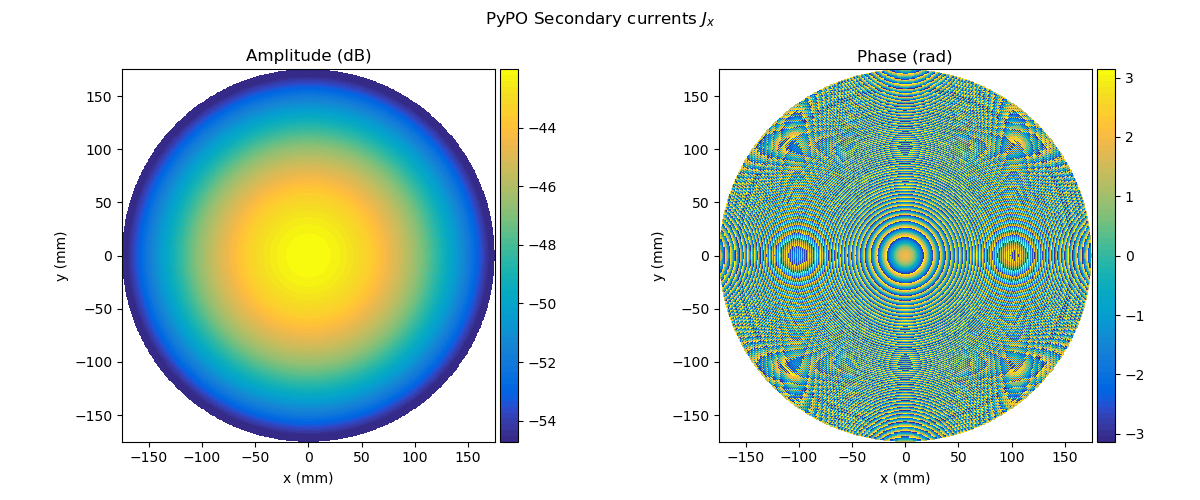

In [5]:
plotBeam2D(grid_sec, JM_sec, comp='Jx', correct_phase=-1, title="PyPO Secondary currents", vmin=-12.7)

/home/pgrimes/github/compare-grasp-pypo/compare/plotters.py:30: RuntimeWarning: divide by zero encountered in log10
  ampplt = ax[0].pcolormesh(field.positions[0], field.positions[1], 20*np.log10(np.abs(field.field[:,:,comp])), cmap=amp_cmap, vmin=vmin, vmax=vmax)


(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': 'Amplitude (dB)'}, xlabel='x (mm)', ylabel='y (mm)'>,
        <Axes: title={'center': 'Phase (rad)'}, xlabel='x (mm)', ylabel='y (mm)'>],
       dtype=object))

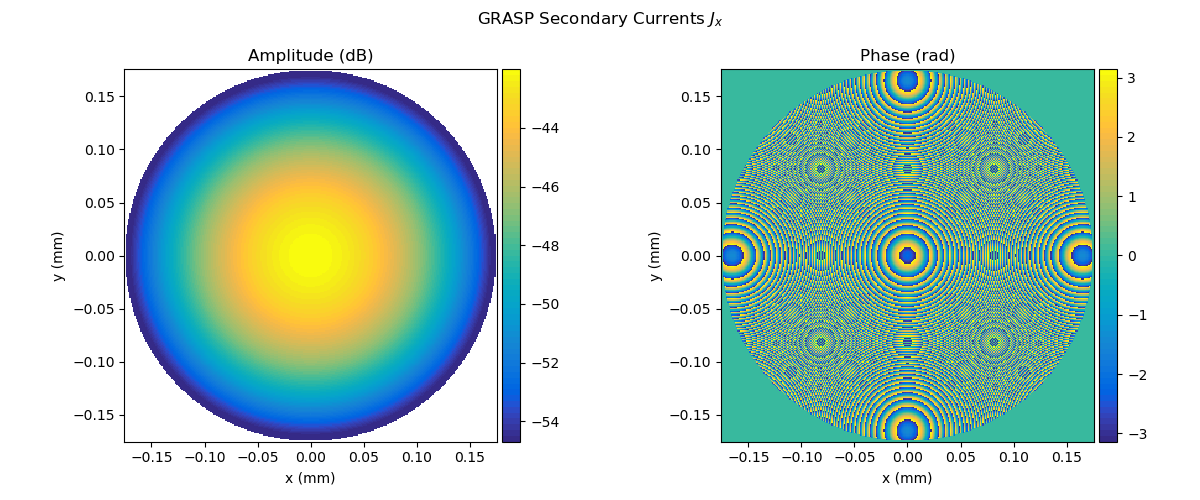

In [6]:
plotGraspBeam2D(GJM_sec.fields[0], comp=0, comp_name='J', title="GRASP Secondary Currents", vmin=-12.7)

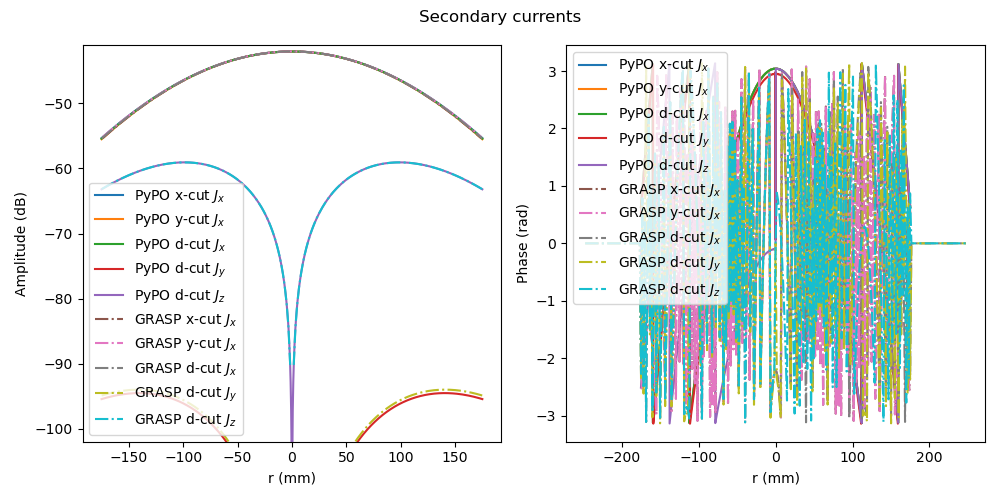

In [10]:
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='x', gmode='uv', comp='Jx', correct_phase=1, title="Secondary currents", label='PyPO x-cut', vmin=-60)
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='y', gmode='uv', comp='Jx', correct_phase=1, figax=(fig, ax), label='PyPO y-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jx', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jy', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotBeamCut(grid_sec, JM_sec, cut='d', gmode='uv', comp='Jz', correct_phase=1, figax=(fig, ax), label='PyPO d-cut')
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='x', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP x-cut')
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='y', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP y-cut')
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=0, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut')
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=1, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut')
fig, ax = plotGraspBeamCut(GJM_sec.fields[0], cut='d', comp=2, comp_name='J', figax=[fig, ax], ls='-.', label='GRASP d-cut')
ax[0].legend(loc='lower left')